Methodology

FICO scores are continuous values ranging from 300 to 850. To make the data compatible with systems requiring categorical inputs, the scores were quantized into ten rating buckets using quantile binning. Each bucket contains approximately the same number of borrowers. For each rating bucket, the historical probability of default (PD) was calculated as:

PD=
Number of Borrowers
Number of Defaults
	​


Lower rating values correspond to better credit quality and lower expected default risk.

An alternative approach is to determine bucket boundaries using maximum likelihood estimation and dynamic programming, which can produce statistically optimal discretizations. For this prototype, quantile-based bucketing was selected due to its simplicity, interpretability, and ability to produce well-separated risk categories.

In [7]:
# ------------------------------------------------------------
# Import Required Libraries & Load Data
# ------------------------------------------------------------

import pandas as pd
import numpy as np

df = pd.read_csv("Task 3 and 4_Loan_Data.csv")

df.head()

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0


In [8]:
# ------------------------------------------------------------
# Explore FICO Score Distribution
# ------------------------------------------------------------

print(df["fico_score"].describe())

print("\nDefault Counts:")
print(df["default"].value_counts())

count    10000.000000
mean       637.557700
std         60.657906
min        408.000000
25%        597.000000
50%        638.000000
75%        679.000000
max        850.000000
Name: fico_score, dtype: float64

Default Counts:
default
0    8149
1    1851
Name: count, dtype: int64


In [10]:
# ------------------------------------------------------------
# Create Rating Buckets
# ------------------------------------------------------------

# Number of desired rating categories
NUM_BUCKETS = 10

# Create quantile-based buckets
# Each bucket contains roughly the same number of borrowers

df["rating"] = pd.qcut(
    df["fico_score"],
    q=NUM_BUCKETS,
    labels=False,
    duplicates="drop"
)

# Reverse ratings so:
# Rating 1 = Best Credit Quality
# Rating 10 = Worst Credit Quality

df["rating"] = (
    NUM_BUCKETS
    - df["rating"]
)

df[["fico_score", "rating"]].head(10)

,fico_score,rating
0,605,8
1,572,9
2,602,8
3,612,7
4,631,6
5,697,2
6,722,1
7,545,10
8,676,3
9,447,10


In [11]:
# ------------------------------------------------------------
# Probability of Default by Rating
# ------------------------------------------------------------

rating_summary = (
    df.groupby("rating")
      .agg(
          borrowers=("default", "count"),
          defaults=("default", "sum"),
          pd=("default", "mean")
      )
      .sort_index()
)

print(rating_summary)

        borrowers  defaults        pd
rating                               
1             988        36  0.036437
2            1005        72  0.071642
3             970        92  0.094845
4            1027       108  0.105161
5             997       128  0.128385
6             992       173  0.174395
7             984       179  0.181911
8             987       246  0.249240
9            1033       318  0.307841
10           1017       499  0.490659


Results

The quantile-based bucketing approach successfully separates borrowers by risk level. Rating 1 borrowers exhibit a historical default rate of approximately 3.6%, while Rating 10 borrowers exhibit a default rate of approximately 49.1%. The monotonic increase in default probability across rating categories suggests that FICO score is a strong predictor of borrower default risk.

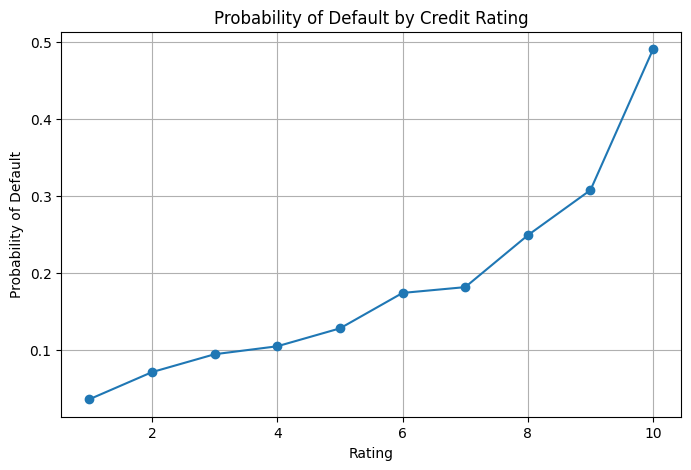

In [16]:
# ------------------------------------------------------------
# Visualize Default Probability by Rating
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    rating_summary.index,
    rating_summary["pd"],
    marker="o"
)

plt.title(
    "Probability of Default by Credit Rating"
)

plt.xlabel("Rating")

plt.ylabel("Probability of Default")

plt.grid(True)

plt.show()

In [12]:
# ------------------------------------------------------------
# Create FICO-to-Rating Mapping Table
# ------------------------------------------------------------

rating_map = (
    df.groupby("rating")
      .agg(
          min_fico=("fico_score", "min"),
          max_fico=("fico_score", "max")
      )
      .sort_index()
)

print(rating_map)

        min_fico  max_fico
rating                    
1            715       850
2            689       714
3            671       688
4            654       670
5            639       653
6            624       638
7            608       623
8            588       607
9            561       587
10           408       560


In [13]:
# ------------------------------------------------------------
# Convert FICO Score to Rating
# ------------------------------------------------------------

def fico_to_rating(fico_score):
    """
    Converts a FICO score into a credit rating.

    Lower rating numbers indicate
    better credit quality.
    """

    for rating, row in rating_map.iterrows():

        if (
            row["min_fico"]
            <= fico_score
            <= row["max_fico"]
        ):
            return int(rating)

    return None

In [14]:
# ------------------------------------------------------------
# Estimate Probability of Default
# ------------------------------------------------------------

def predict_pd_from_fico(fico_score):
    """
    Returns the estimated probability
    of default based on FICO score.
    """

    rating = fico_to_rating(fico_score)

    if rating is None:
        return None

    return float(
        rating_summary.loc[
            rating,
            "pd"
        ]
    )

In [15]:
# ------------------------------------------------------------
# Example Borrowers
# ------------------------------------------------------------

scores = [500, 600, 700, 800]

for score in scores:

    rating = fico_to_rating(score)

    pd_estimate = predict_pd_from_fico(score)

    print(
        f"FICO: {score}, "
        f"Rating: {rating}, "
        f"PD: {pd_estimate:.4f}"
    )

FICO: 500, Rating: 10, PD: 0.4907
FICO: 600, Rating: 8, PD: 0.2492
FICO: 700, Rating: 2, PD: 0.0716
FICO: 800, Rating: 1, PD: 0.0364


Conclusion

FICO scores were successfully quantized into ten credit rating categories using quantile-based bucketing. The resulting rating system demonstrates a clear monotonic relationship between credit rating and probability of default. Borrowers in Rating 1 exhibit a default rate of approximately 3.6%, while borrowers in Rating 10 exhibit a default rate of approximately 49.1%. This indicates that the rating map effectively captures credit risk and can be used as a categorical input for downstream machine learning models.